## FIFA 21 Player Stats Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('charts', exist_ok=True)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## Load Dataset

In [3]:
df = pd.read_csv('fifa21.csv')
print('Raw Shape:', df.shape)

Raw Shape: (16155, 106)


In [4]:
# Selecting relevant columns, checking missing values & duplicates
df = df[['short_name', 'age', 'nationality', 'club_name', 'overall', 'potential',
         'value_eur', 'wage_eur', 'player_positions',
         'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']]

df.dropna(inplace=True)
print('Clean Shape:', df.shape)
print('Missing Values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df.head()

Clean Shape: (14178, 15)
Missing Values: 0
Duplicates: 0


,short_name,age,nationality,club_name,overall,potential,value_eur,wage_eur,player_positions,pace,shooting,passing,dribbling,defending,physic
0,L. Messi,27,Argentina,FC Barcelona,93,95,100500000,550000,CF,93.0,89.0,86.0,96.0,27.0,63.0
1,Cristiano Ronaldo,29,Portugal,Real Madrid,92,92,79000000,375000,"LW, LM",93.0,93.0,81.0,91.0,32.0,79.0
2,A. Robben,30,Netherlands,FC Bayern München,90,90,54500000,275000,"RM, LM, RW",93.0,86.0,83.0,92.0,32.0,64.0
3,Z. Ibrahimović,32,Sweden,Paris Saint-Germain,90,90,52500000,275000,ST,76.0,91.0,81.0,86.0,34.0,86.0
5,L. Suárez,27,Uruguay,FC Barcelona,89,91,49500000,300000,"ST, CF",83.0,87.0,79.0,88.0,42.0,79.0


## Feature Engineering

In [5]:
# Convert value and wage to millions/thousands for readability
df['value_million'] = df['value_eur'] / 1e6
df['wage_thousand'] = df['wage_eur'] / 1000

In [6]:
# Bin ages into groups for cleaner analysis
df['age_group'] = pd.cut(df['age'],
                          bins=[15, 20, 25, 30, 35, 45],
                          labels=['15-20', '21-25', '26-30', '31-35', '36+'])

print('Features ready.')
df.info()

Features ready.
<class 'pandas.core.frame.DataFrame'>
Index: 14178 entries, 0 to 16154
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   short_name        14178 non-null  object  
 1   age               14178 non-null  int64   
 2   nationality       14178 non-null  object  
 3   club_name         14178 non-null  object  
 4   overall           14178 non-null  int64   
 5   potential         14178 non-null  int64   
 6   value_eur         14178 non-null  int64   
 7   wage_eur          14178 non-null  int64   
 8   player_positions  14178 non-null  object  
 9   pace              14178 non-null  float64 
 10  shooting          14178 non-null  float64 
 11  passing           14178 non-null  float64 
 12  dribbling         14178 non-null  float64 
 13  defending         14178 non-null  float64 
 14  physic            14178 non-null  float64 
 15  value_million     14178 non-null  float64 
 16  wage_thousa

## Exploratory Data Analysis

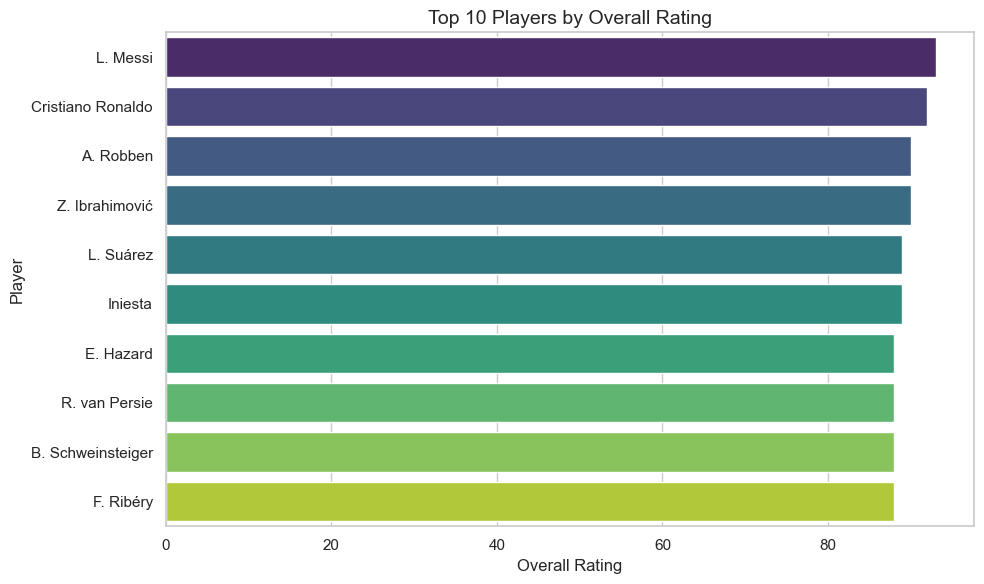

In [7]:
# 1. Top 10 players by overall rating
top_overall = df.sort_values(by='overall', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='overall', y='short_name', data=top_overall,
            hue='short_name', palette='viridis', legend=False)
plt.title('Top 10 Players by Overall Rating', fontsize=14)
plt.xlabel('Overall Rating')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('charts/top10_overall.png', bbox_inches='tight')
plt.show()

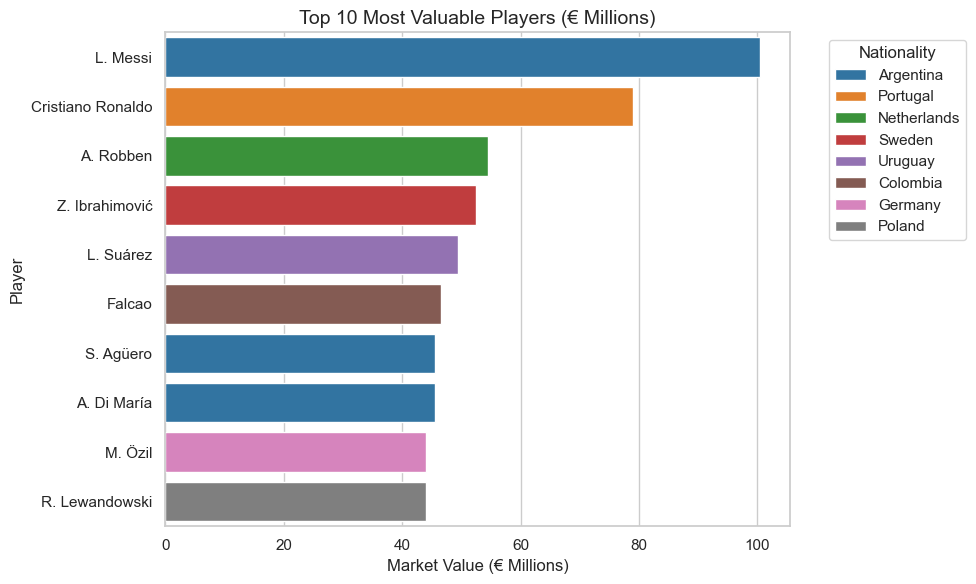

In [8]:
# 2. Top 10 most valuable players
top_value = df.sort_values(by='value_eur', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='value_million', y='short_name', data=top_value,
            hue='nationality', palette='tab10')
plt.title('Top 10 Most Valuable Players (€ Millions)', fontsize=14)
plt.xlabel('Market Value (€ Millions)')
plt.ylabel('Player')
plt.legend(title='Nationality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('charts/top10_value.png', bbox_inches='tight')
plt.show()

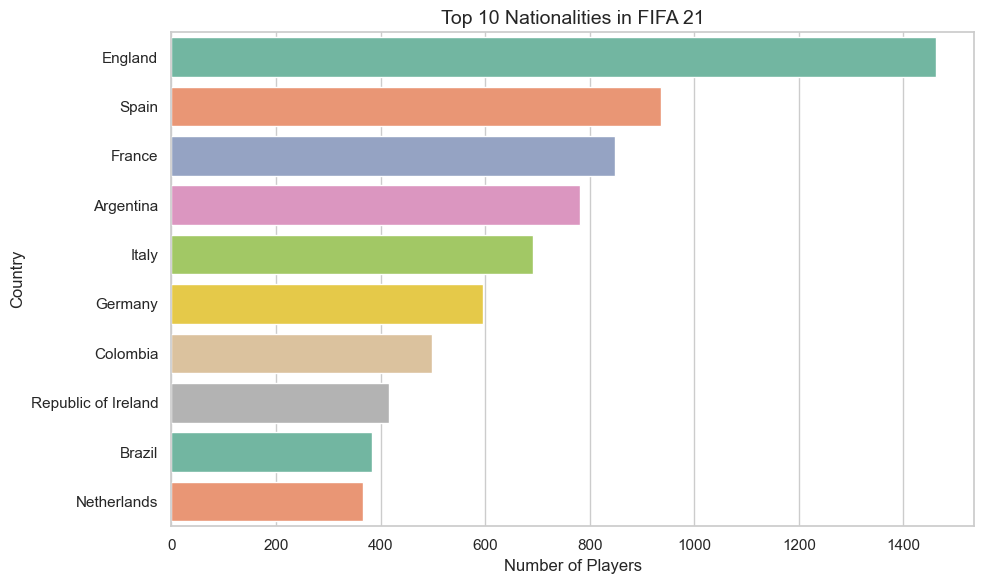

In [9]:
# 3. Top 10 nationalities in FIFA 21
top_countries = df['nationality'].value_counts().head(10).reset_index()
top_countries.columns = ['nationality', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_countries, x='count', y='nationality',
            hue='nationality', palette='Set2', legend=False)
plt.title('Top 10 Nationalities in FIFA 21', fontsize=14)
plt.xlabel('Number of Players')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('charts/top10_countries.png', bbox_inches='tight')
plt.show()

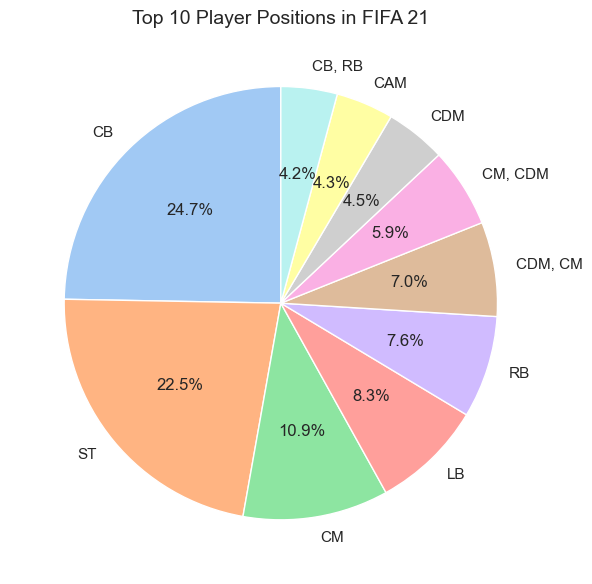

In [10]:
# 4. Top 10 player positions distribution
top_positions = df['player_positions'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_positions.plot.pie(autopct='%1.1f%%',
                        colors=sns.color_palette('pastel'),
                        startangle=90)
plt.title('Top 10 Player Positions in FIFA 21', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.savefig('charts/top10_positions_pie.png', bbox_inches='tight')
plt.show()

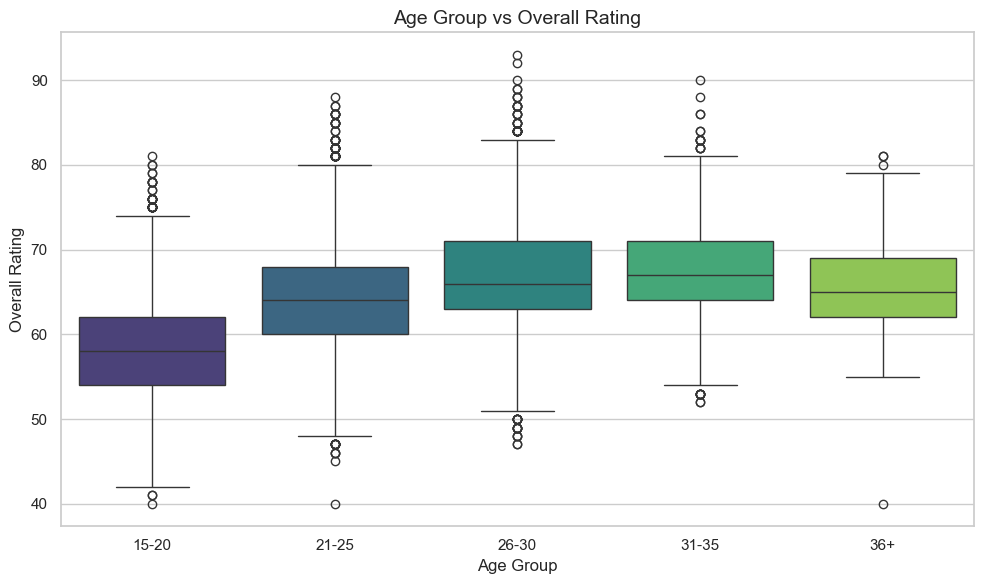

In [11]:
# 5. Age group vs overall rating
plt.figure(figsize=(10, 6))
sns.boxplot(x='age_group', y='overall', data=df,
            hue='age_group', palette='viridis', legend=False)
plt.title('Age Group vs Overall Rating', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Overall Rating')
plt.tight_layout()
plt.savefig('charts/age_vs_overall.png', bbox_inches='tight')
plt.show()

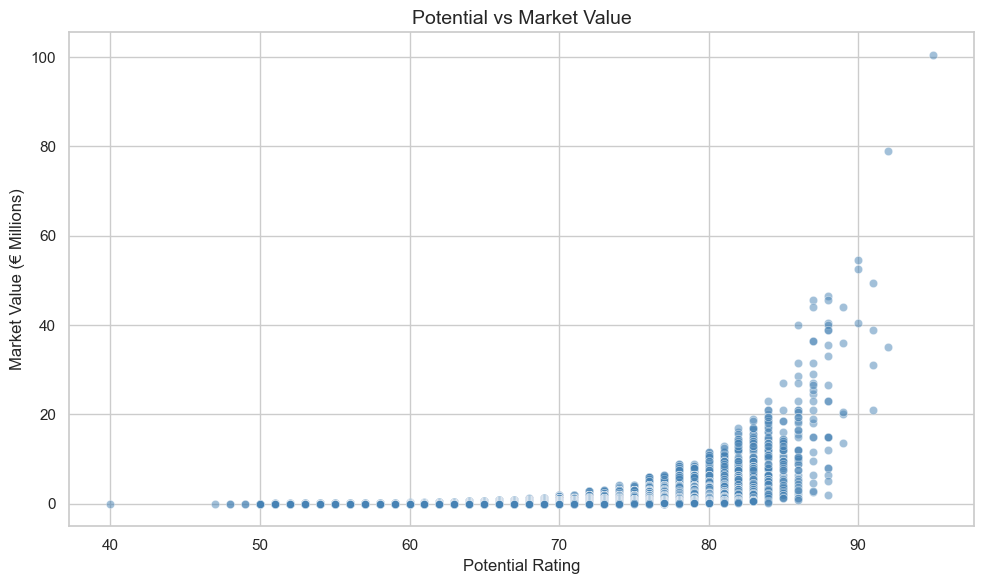

In [12]:
# 6. Potential vs market value
plt.figure(figsize=(10, 6))
sns.scatterplot(x='potential', y='value_million', data=df,
                alpha=0.5, color='steelblue')
plt.title('Potential vs Market Value', fontsize=14)
plt.xlabel('Potential Rating')
plt.ylabel('Market Value (€ Millions)')
plt.tight_layout()
plt.savefig('charts/potential_vs_value.png', bbox_inches='tight')
plt.show()

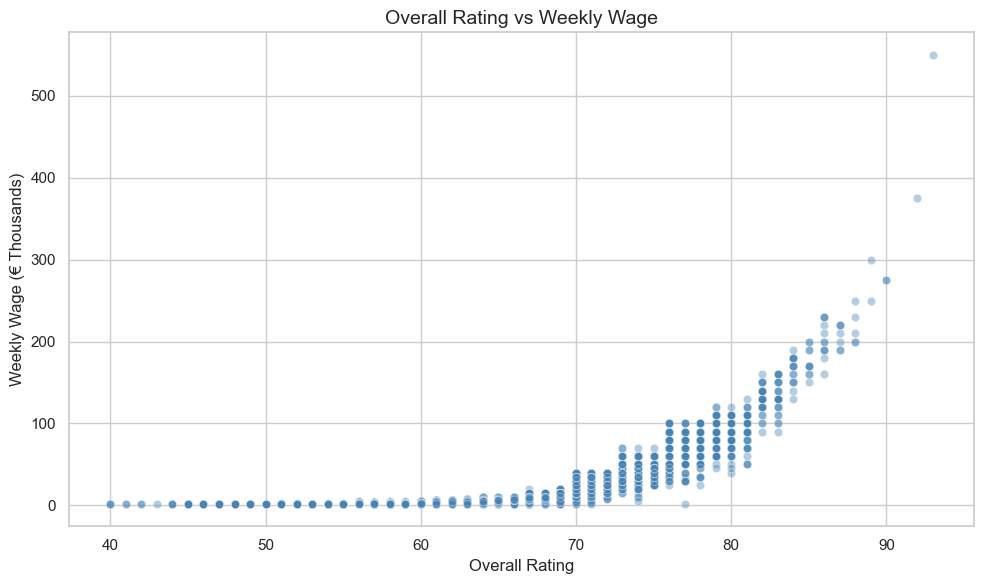

In [13]:
# 7. Overall rating vs weekly wage
plt.figure(figsize=(10, 6))
sns.scatterplot(x='overall', y='wage_thousand', data=df,
                alpha=0.4, color='steelblue')
plt.title('Overall Rating vs Weekly Wage', fontsize=14)
plt.xlabel('Overall Rating')
plt.ylabel('Weekly Wage (€ Thousands)')
plt.tight_layout()
plt.savefig('charts/overall_vs_wage.png', bbox_inches='tight')
plt.show()

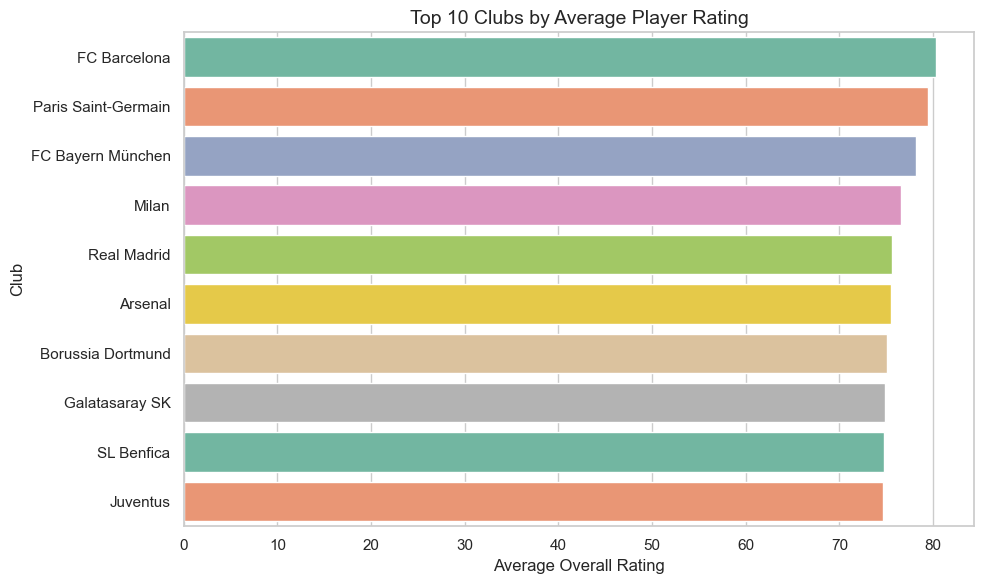

In [14]:
# 8. Top 10 clubs by average overall rating
top_clubs = df.groupby('club_name')['overall'].mean().sort_values(
            ascending=False).head(10).reset_index()
top_clubs.columns = ['club_name', 'avg_overall']
top_clubs['avg_overall'] = top_clubs['avg_overall'].round(2)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_clubs, x='avg_overall', y='club_name',
            hue='club_name', palette='Set2', legend=False)
plt.title('Top 10 Clubs by Average Player Rating', fontsize=14)
plt.xlabel('Average Overall Rating')
plt.ylabel('Club')
plt.tight_layout()
plt.savefig('charts/top10_clubs.png', bbox_inches='tight')
plt.show()

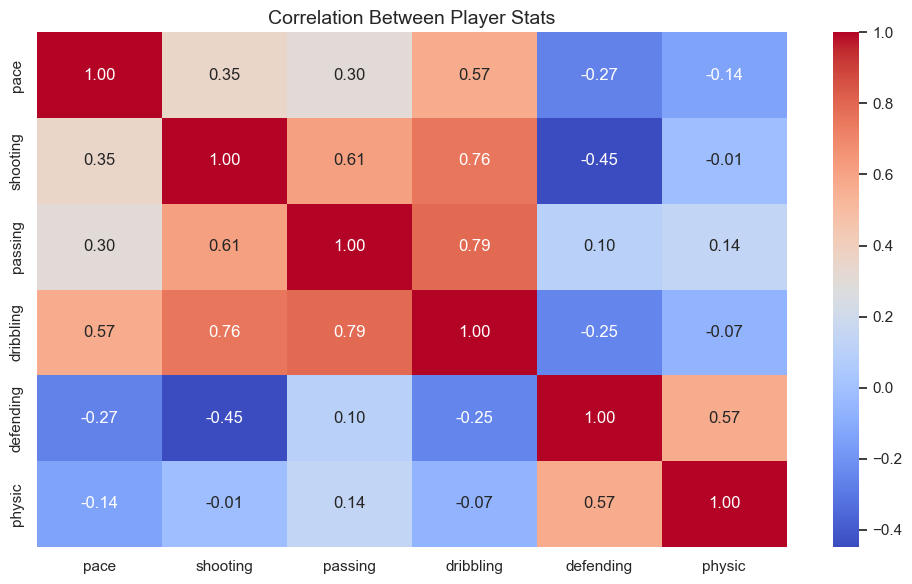

In [15]:
# 9. Correlation heatmap for player stats
plt.figure(figsize=(10, 6))
numeric_stats = df[['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']]
sns.heatmap(numeric_stats.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Player Stats', fontsize=14)
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Key Insights

In [16]:
top_player = df.loc[df['overall'].idxmax(), 'short_name']
top_valued = df.loc[df['value_eur'].idxmax(), 'short_name']
top_country = df['nationality'].value_counts().idxmax()
top_club = top_clubs.iloc[0]['club_name']
peak_age = df.groupby('age_group', observed=True)['overall'].mean().idxmax()

print('=' * 55)
print('           KEY INSIGHTS — FIFA 21')
print('=' * 55)
print(f'Total Players Analyzed : {len(df):,}')
print(f'Highest Rated Player   : {top_player}')
print(f'Most Valuable Player   : {top_valued}')
print(f'Top Nationality        : {top_country}')
print(f'Top Club (Avg Rating)  : {top_club}')
print(f'Peak Performance Age   : {peak_age}')
print('=' * 55)

           KEY INSIGHTS — FIFA 21
Total Players Analyzed : 14,178
Highest Rated Player   : L. Messi
Most Valuable Player   : L. Messi
Top Nationality        : England
Top Club (Avg Rating)  : FC Barcelona
Peak Performance Age   : 31-35
